In [1]:
import pandas as pd
from os import listdir
from os.path import isfile, join

In [2]:
def get_abs(abs_df, plate_template, absorbance, line):
    '''
    Function to extract the particular absorbance of a certain cell line and return that as a list
    
    Variables:
        abs_df = the pandas dataframe that contains the absorbances of all cell lines
        plate_template = the positioning of the lines on each of the cell plates
        absorbance = well...pretty self explainatory 
        line = cell line that you're intersted in 
    '''
    
    #first reformat the last column of the spreadsheet to only contain the absorbance as a number
    abs_df["Unnamed: 14"] = pd.to_numeric(abs_df["Unnamed: 14"].replace("Read [123]:", "", regex = True))
    #Filter by absorbance
    filtered_df = abs_df.loc[abs_df["Unnamed: 14"] == absorbance].reset_index(drop=True)
    #Filter by line
    values = filtered_df.where(plate_template == line).apply(lambda x: x.dropna().to_list())
    #Filter to only get lists with items 
    if isinstance(values, pd.DataFrame):
        return [0,0,0,0,0,0,0,0]
    
    else:
        abs_list = values[values.str.len() > 0].to_list()
        #Flatten the list (i.e. condense it to 1 list)
        abs_list = sum(abs_list, [])
        return np.array(abs_list)

In [3]:
cell_lines = [3059, 1691, 1690, 2342, 4532, 2344, 2343, 1952, 2931, "JG5", "BMS"] #2932
abs_lst = [680,750]
temperature = [25, 20, 30]

#Get the positions of the lines on their plates
plate_template = pd.read_excel("Plate_template.xlsx", sheet_name = 0)

In [4]:
absorbance_dict = {}
temp_data = [53,104,155]# Line numbers of where the temperature data starts
#go through the excel files in the cwd
for f in listdir("./"):
    if f == "Plate_template.xlsx":
        continue
    print(f)
    f_name = f.strip().split(".")
    #only look at files that end in an xl format
    if isfile(join("./", f)) and (f_name[-1][:2] == "xl"):
        for index in [0,1,2]: 
            #go through every plate layout in the file (0 = 25°C, 1 = 30°C, 2 = 35°C)
            abs_df = pd.read_excel(f, usecols = "B:O", skiprows = temp_data[index], nrows = 48)
            for line in cell_lines:
                for absorb in abs_lst:
                    key = "{abso}_{temp}_{cell_line}".format(abso = absorb, temp = temperature[index], cell_line = line)
                    abs_data = get_abs(abs_df, plate_template, absorb, line)
                    if len(abs_data) >= 8:
                        absorbance_dict[f_name[0]+"_"+key] = list(abs_data)
                        if len(abs_data) != 8:
                            print(key)

20230713-3PM.xls
.DS_Store
20230712-3PM.xls
20230711-9AM.xls
20230710-3PM.xls
20230710-11AM.xls
20230713-9AM.xls
20230714-9PM.xls
20230712-9AM.xls
20230711-3PM.xls
20230714-3PM.xls
Spec_Script_25_20_30.ipynb
20230710-9PM.xls
20230711-9PM.xls
.ipynb_checkpoints
20230713-9PM.xls
20230714-9AM.xls
20230712-9PM.xls


In [20]:
#len(absorbance_dict["20230703-9pm_680_25_2344"])

In [5]:
data_sorted = pd.DataFrame(absorbance_dict)

data_sorted.shape
data_sorted["Replicate"] = data_sorted.index
print(data_sorted.shape)
data_sorted

(8, 991)


,20230713-3PM_680_25_3059,20230713-3PM_750_25_3059,20230713-3PM_680_25_1691,20230713-3PM_750_25_1691,20230713-3PM_680_25_1690,20230713-3PM_750_25_1690,20230713-3PM_680_25_2342,20230713-3PM_750_25_2342,20230713-3PM_680_25_4532,20230713-3PM_750_25_4532,...,20230712-9PM_750_30_2343,20230712-9PM_680_30_1952,20230712-9PM_750_30_1952,20230712-9PM_680_30_2931,20230712-9PM_750_30_2931,20230712-9PM_680_30_JG5,20230712-9PM_750_30_JG5,20230712-9PM_680_30_BMS,20230712-9PM_750_30_BMS,Replicate
0,1.938,1.198,2.598,1.333,1.936,1.160,1.228,0.906,1.733,1.029,...,0.968,1.471,0.803,1.645,0.913,1.570,0.732,1.669,0.837,0
1,1.873,1.267,2.216,1.208,2.779,1.382,1.781,1.122,1.769,0.971,...,0.929,1.511,0.819,1.539,0.860,1.237,0.628,1.445,0.797,1
2,1.578,1.113,1.362,0.720,0.847,0.536,1.381,1.022,1.751,0.994,...,1.072,1.576,0.883,1.636,0.887,0.898,0.450,0.740,0.423,2
3,1.830,1.218,2.131,1.237,1.684,0.976,1.608,1.061,1.619,0.851,...,1.014,1.745,1.022,1.358,0.835,0.948,0.490,2.061,0.991,3
4,2.135,1.265,1.110,0.688,1.755,1.088,1.316,0.856,1.880,1.085,...,0.629,1.594,0.837,1.585,0.861,1.090,0.549,1.558,0.902,4
5,1.868,1.200,2.343,1.287,1.642,0.913,1.396,1.006,1.801,0.998,...,1.106,1.524,0.878,1.839,0.961,1.129,0.550,1.583,0.949,5
6,1.583,1.126,1.503,0.909,1.633,0.943,1.773,1.083,2.032,1.050,...,0.705,1.586,0.894,1.587,0.931,1.112,0.550,0.649,0.405,6
7,1.662,1.110,1.523,0.904,1.609,0.949,1.242,0.971,2.019,0.998,...,0.813,2.185,1.038,1.674,1.079,1.357,0.653,1.467,0.813,7


In [6]:
data_sorted = data_sorted.melt(id_vars = ["Replicate"])
print(data_sorted.shape)
data_sorted["ID"] = data_sorted["variable"].astype("str") + "_"+ data_sorted["Replicate"].astype("str")
data_sorted = data_sorted[["ID","value"]]

(7920, 3)


In [7]:
#Reformat the dataframe
from datetime import datetime

data_sorted[['Hours', 'Absorbance', 'Temperature', 'Cell_Line', 'Replicate']] = data_sorted.ID.str.split("_", expand = True)
data_sorted[['Absorbance', 'Temperature', 'Replicate']] = data_sorted[['Absorbance', 'Temperature', 'Replicate']].apply(pd.to_numeric, errors='coerce', axis=1)
# data_sorted[["Cell_Line"]] = data_sorted[["Cell_Line"]].astype(int)

#Reformat the time and date column
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("am", "AM", regex=True)
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("pm", "PM", regex=True)
data_sorted["Hours"]  = pd.to_datetime(data_sorted["Hours"], format='%Y%m%d-%I%p')
data_sorted["Hours"] = (data_sorted["Hours"] - min(data_sorted["Hours"]))/np.timedelta64(1, 'h')

#ln transfomring the data
data_sorted["log10_transformed"] = pd.to_numeric(np.log10(data_sorted["value"]))


data_sorted.shape

(7920, 8)

In [8]:
data_sorted.head()
pd.unique(data_sorted.Cell_Line)

array(['3059', '1691', '1690', '2342', '4532', '2344', '2343', '1952',
       '2931', 'JG5', 'BMS'], dtype=object)

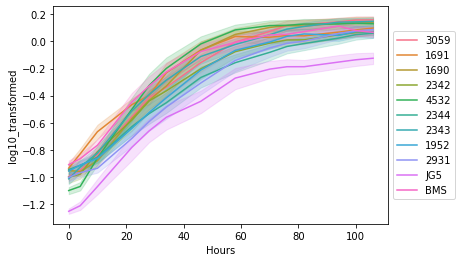

In [10]:
import seaborn as sns

plt = sns.lineplot(data = data_sorted, x = "Hours", y = "log10_transformed", hue = "Cell_Line")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

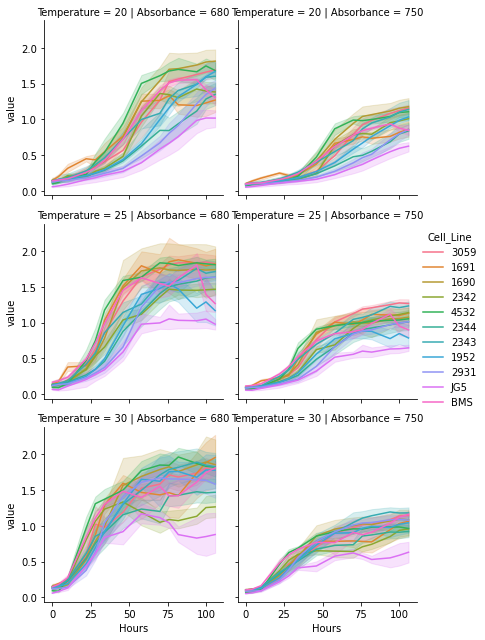

In [11]:
g = sns.FacetGrid(data_sorted, row="Temperature", col = "Absorbance", hue = "Cell_Line")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

In [9]:
data_sorted.to_csv("../../Cleaned_Data/25_20_30.csv")
data_sorted.head()

,ID,value,Hours,Absorbance,Temperature,Cell_Line,Replicate,log10_transformed
0,20230713-3PM_680_25_3059_0,1.938,76.0,680,25,3059,0,0.287354
1,20230713-3PM_680_25_3059_1,1.873,76.0,680,25,3059,1,0.272538
2,20230713-3PM_680_25_3059_2,1.578,76.0,680,25,3059,2,0.198107
3,20230713-3PM_680_25_3059_3,1.830,76.0,680,25,3059,3,0.262451
4,20230713-3PM_680_25_3059_4,2.135,76.0,680,25,3059,4,0.329398


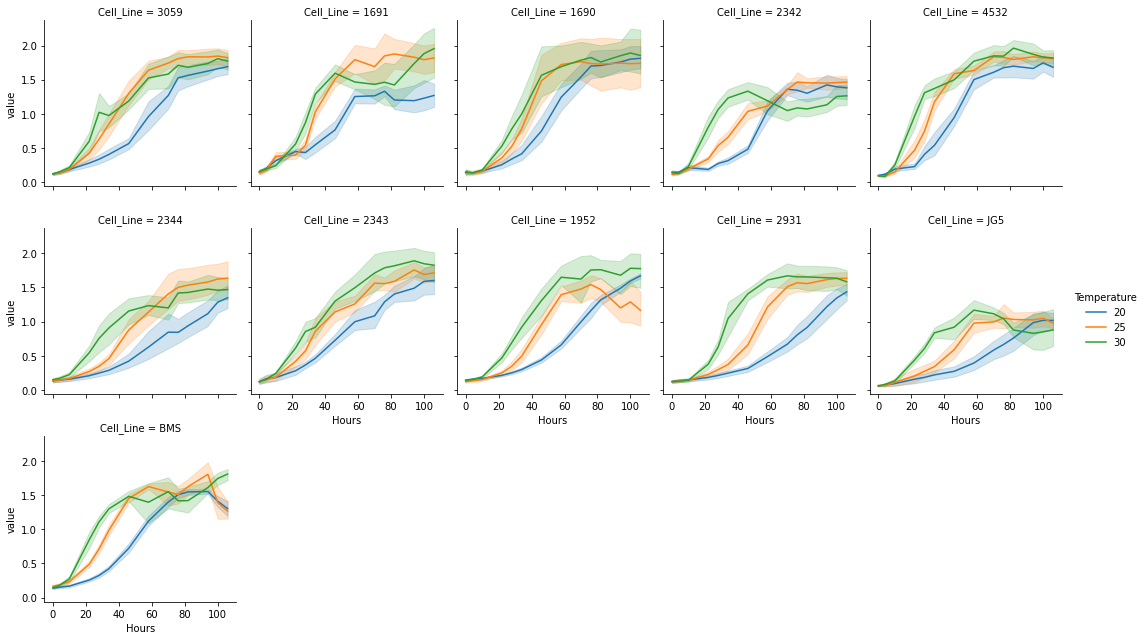

In [13]:
g = sns.FacetGrid(data_sorted[data_sorted["Absorbance"] == 680], col = "Cell_Line", col_wrap = 5, hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

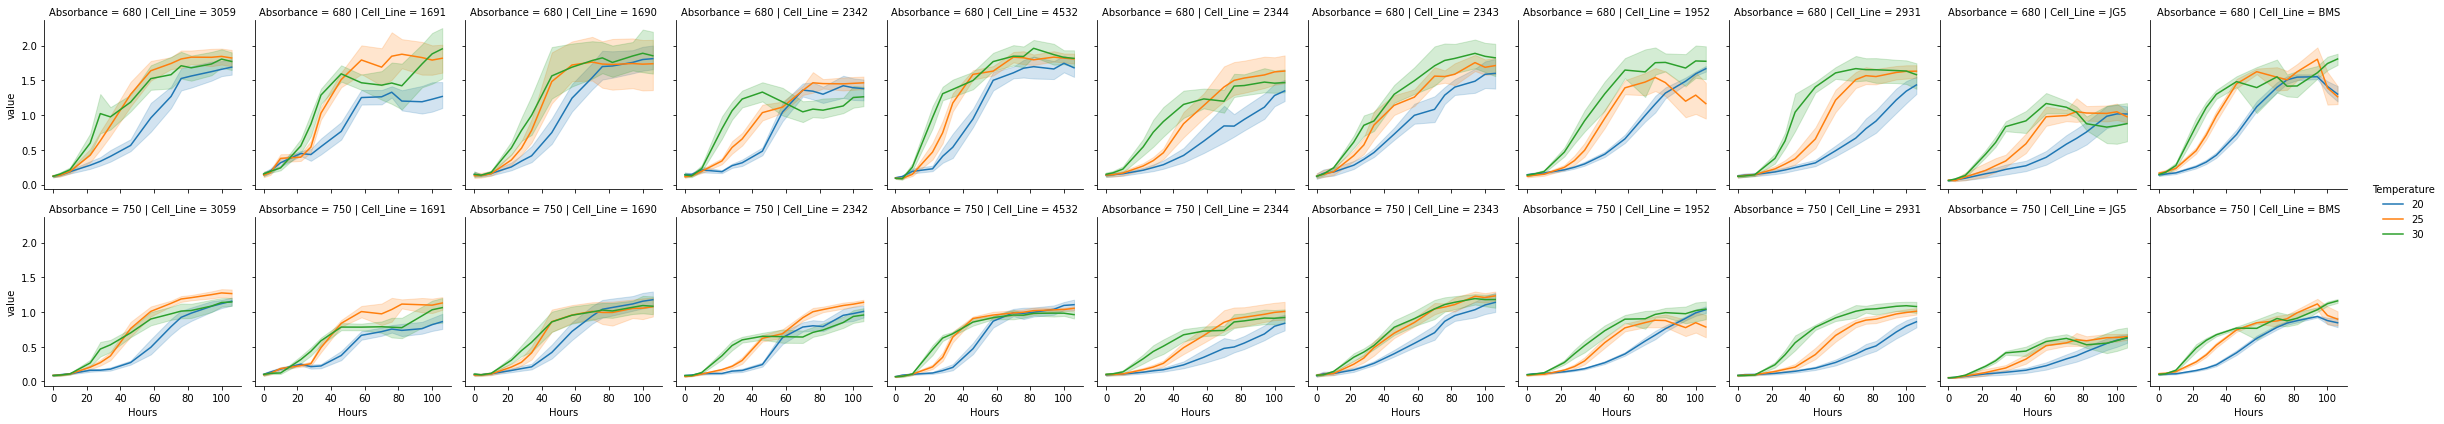

In [14]:
g = sns.FacetGrid(data_sorted, col="Cell_Line", row = "Absorbance", hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()